# 1. A/B Test Analysis for Data Explorer

# 1.1 Read A/B metrics CSV

In [7]:
import os
import numpy as np
import pandas as pd
from scipy.stats import fisher_exact, norm

csv_path = r"C:/Users/35759/Desktop/ab_metrics.csv"

ab_data = pd.read_csv(csv_path)

# Basic cleaning
for col in ["session_id", "event", "variant", "condition", "button_text", "dataset", "tab"]:
    if col in ab_data.columns:
        ab_data[col] = ab_data[col].astype(str)

ab_data["seconds_from_start"] = pd.to_numeric(
    ab_data["seconds_from_start"],
    errors="coerce"
)

print("\n==============================")
print("Raw data preview")
print("==============================")
print(ab_data.head())

print("\nColumns in CSV:")
print(ab_data.columns.tolist())


Raw data preview
                    session_id                event variant    condition  \
0  session_20260419210247_9738      session_started       B  Treatment B   
1  session_20260419210247_9738           tab_viewed       B  Treatment B   
2  session_20260419210247_9738  demo_cta_impression       B  Treatment B   
3  session_20260419210247_9738  demo_button_clicked       B  Treatment B   
4  session_20260419210247_9738  demo_dataset_loaded       B  Treatment B   

                  button_text dataset           tab  seconds_from_start  \
0  Try Demo Dataset Instantly     nan    User Guide               0.148   
1  Try Demo Dataset Instantly     nan  Data Loading               1.266   
2  Try Demo Dataset Instantly    none  Data Loading               1.320   
3  Try Demo Dataset Instantly    iris  Data Loading              12.001   
4  Try Demo Dataset Instantly    iris  Data Loading              12.014   

                    timestamp  
0  2026-04-19 21:02:48.007364  
1  2026-04

# 1.2 Check event counts and Convert event-level data to session-level data

In [19]:
event_counts = (
    ab_data
    .groupby(["variant", "event"])
    .size()
    .reset_index(name="event_count")
    .sort_values(["variant", "event"])
)

print("\n==============================")
print("Event counts by variant")
print("==============================")
print(event_counts)

# Each row represents one session.

def has_event(events, event_name):
    return event_name in set(events)


def first_action_time(group):
    values = group.loc[group["event"] == "first_action_completed", "seconds_from_start"]
    values = values.dropna()
    if len(values) == 0:
        return np.nan
    return values.min()


session_summary = (
    ab_data
    .groupby(["session_id", "variant", "condition", "button_text"], dropna=False)
    .apply(
        lambda g: pd.Series({
            "saw_demo_cta": has_event(g["event"], "demo_cta_impression"),
            "clicked_demo_button": has_event(g["event"], "demo_button_clicked"),
            "demo_load_failed": has_event(g["event"], "demo_load_failed"),
            "loaded_demo_dataset": has_event(g["event"], "demo_dataset_loaded"),
            "completed_first_action": has_event(g["event"], "first_action_completed"),
            "applied_cleaning": has_event(g["event"], "cleaning_options_applied"),
            "applied_feature_engineering": has_event(g["event"], "feature_engineering_applied"),
            "had_error": has_event(g["event"], "error_occurred"),
            "time_to_first_action": first_action_time(g)
        })
    )
    .reset_index()
)

session_summary["downstream_engagement"] = (
    session_summary["applied_cleaning"] |
    session_summary["applied_feature_engineering"]
)

print("\n==============================")
print("Session-level summary")
print("==============================")
print(session_summary)


Event counts by variant
   variant                        event  event_count
0        A          demo_button_clicked            6
1        A          demo_cta_impression           20
2        A          demo_dataset_loaded            6
3        A                file_uploaded            3
4        A       first_action_completed            8
5        A              session_started           20
6        A                   tab_viewed           49
7        B          demo_button_clicked           27
8        B          demo_cta_impression           24
9        B          demo_dataset_loaded           24
10       B             demo_load_failed            3
11       B           eda_plot_generated           21
12       B  feature_engineering_applied            1
13       B                file_uploaded            3
14       B       first_action_completed           22
15       B              session_started           24
16       B                   tab_viewed          132

Session-level summar

C:\Users\35759\AppData\Local\Temp\ipykernel_31028\2912096160.py:31: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(


# 1.3 Keep sessions that actually saw the demo CTA and Summary table by A/B group

In [9]:
analysis_data = session_summary[session_summary["saw_demo_cta"]].copy()

print("\n==============================")
print("Sessions used in CTA analysis")
print("==============================")
print(analysis_data)

ab_summary = (
    analysis_data
    .groupby(["variant", "condition", "button_text"], dropna=False)
    .agg(
        sessions=("session_id", "count"),
        demo_clicks=("clicked_demo_button", "sum"),
        demo_loaded=("loaded_demo_dataset", "sum"),
        first_actions=("completed_first_action", "sum"),
        downstream_actions=("downstream_engagement", "sum"),
        errors=("had_error", "sum"),
        avg_time_to_first_action=("time_to_first_action", "mean")
    )
    .reset_index()
)

ab_summary["ctr"] = ab_summary["demo_clicks"] / ab_summary["sessions"]
ab_summary["demo_load_rate"] = ab_summary["demo_loaded"] / ab_summary["sessions"]
ab_summary["first_action_rate"] = ab_summary["first_actions"] / ab_summary["sessions"]
ab_summary["downstream_engagement_rate"] = ab_summary["downstream_actions"] / ab_summary["sessions"]
ab_summary["error_rate"] = ab_summary["errors"] / ab_summary["sessions"]

print("\n==============================")
print("A/B Summary by Variant")
print("==============================")
print(ab_summary)



Sessions used in CTA analysis
                     session_id variant    condition  \
0   session_20260419210247_9738       B  Treatment B   
1   session_20260419210319_6253       A    Control A   
2   session_20260419210333_3969       A    Control A   
3   session_20260419210342_9848       B  Treatment B   
4   session_20260419210344_2406       A    Control A   
5   session_20260419210350_4988       B  Treatment B   
6   session_20260419210406_5748       B  Treatment B   
7   session_20260419210417_1064       B  Treatment B   
8   session_20260419210510_8017       A    Control A   
9   session_20260419210515_4926       B  Treatment B   
10  session_20260419210605_8252       B  Treatment B   
11  session_20260419210626_8108       B  Treatment B   
12  session_20260419210655_7256       B  Treatment B   
13  session_20260419210702_7977       A    Control A   
14  session_20260419210708_2515       A    Control A   
15  session_20260419210719_7213       B  Treatment B   
16  session_20260

# 1.4 Statistical test helper

In [12]:
def two_proportion_z_test(successes, totals, alternative="less"):
    """
    Two-proportion z-test.

    alternative = "less" tests whether p_A < p_B,
    assuming the input order is [A, B].
    """
    x1, x2 = successes
    n1, n2 = totals

    p1 = x1 / n1
    p2 = x2 / n2

    pooled = (x1 + x2) / (n1 + n2)
    se = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))

    if se == 0:
        return {
            "z_stat": np.nan,
            "p_value": np.nan,
            "p_A": p1,
            "p_B": p2
        }

    z = (p1 - p2) / se

    if alternative == "less":
        p_value = norm.cdf(z)
    elif alternative == "greater":
        p_value = 1 - norm.cdf(z)
    else:
        p_value = 2 * min(norm.cdf(z), 1 - norm.cdf(z))

    return {
        "z_stat": z,
        "p_value": p_value,
        "p_A": p1,
        "p_B": p2
    }


def run_prop_test(data, outcome_col, metric_name):
    """
    Compare A vs B for a binary session-level outcome.

    This code assumes:
    A = control group
    B = treatment group

    The alternative hypothesis is:
    H1: p_B > p_A

    Since the table is ordered A then B, this is tested as:
    p_A < p_B
    """

    test_table = (
        data
        .groupby("variant")
        .agg(
            successes=(outcome_col, "sum"),
            total=("session_id", "count")
        )
        .reset_index()
        .sort_values("variant")
    )

    test_table["rate"] = test_table["successes"] / test_table["total"]

    print("\n==============================")
    print(metric_name)
    print("==============================")
    print(test_table)

    if set(test_table["variant"]) != {"A", "B"}:
        print("Warning: Need both A and B variants for this test.")
        return None

    # Force order A, B
    test_table = test_table.set_index("variant").loc[["A", "B"]].reset_index()

    successes = test_table["successes"].astype(int).to_numpy()
    totals = test_table["total"].astype(int).to_numpy()
    failures = totals - successes

    contingency_table = np.array([
        [successes[0], failures[0]],
        [successes[1], failures[1]]
    ])

    print("\nContingency table:")
    print(pd.DataFrame(
        contingency_table,
        index=["A", "B"],
        columns=["Success", "Failure"]
    ))

    # Use Fisher's exact test if any cell is small
    if (contingency_table < 5).any():
        odds_ratio, p_value = fisher_exact(contingency_table, alternative="less")
        test_used = "Fisher's exact test"
        test_result = {
            "odds_ratio": odds_ratio,
            "p_value": p_value
        }
    else:
        z_result = two_proportion_z_test(
            successes=successes,
            totals=totals,
            alternative="less"
        )
        test_used = "Two-proportion z-test"
        test_result = z_result

    print("\nTest used:", test_used)
    print("Test result:", test_result)

    return {
        "metric": metric_name,
        "table": test_table,
        "contingency_table": contingency_table,
        "test_used": test_used,
        "test_result": test_result
    }

# 1.5 Run A/B tests and Simple interpretation template

In [11]:
primary_test = run_prop_test(
    analysis_data,
    outcome_col="loaded_demo_dataset",
    metric_name="Primary Metric: Demo Dataset Load Rate"
)

ctr_test = run_prop_test(
    analysis_data,
    outcome_col="clicked_demo_button",
    metric_name="Secondary Metric: CTR"
)

first_action_test = run_prop_test(
    analysis_data,
    outcome_col="completed_first_action",
    metric_name="Secondary Metric: First Action Completion Rate"
)

downstream_test = run_prop_test(
    analysis_data,
    outcome_col="downstream_engagement",
    metric_name="Secondary Metric: Downstream Engagement Rate"
)

desktop_dir = r"C:/Users/35759/Desktop"

session_summary_path = os.path.join(desktop_dir, "ab_session_summary.csv")
ab_summary_path = os.path.join(desktop_dir, "ab_test_summary_by_variant.csv")
event_counts_path = os.path.join(desktop_dir, "ab_event_counts_by_variant.csv")

session_summary.to_csv(session_summary_path, index=False)
ab_summary.to_csv(ab_summary_path, index=False)
event_counts.to_csv(event_counts_path, index=False)

print("\n==============================")
print("Saved output files")
print("==============================")
print(session_summary_path)
print(ab_summary_path)
print(event_counts_path)

print("\n==============================")
print("Interpretation guide")
print("==============================")

if primary_test is not None:
    result = primary_test["test_result"]
    p_value = result.get("p_value", np.nan)

    print("Primary metric: demo dataset load rate.")
    print("H0: Version A and Version B have the same demo dataset load rate.")
    print("H1: Version B has a higher demo dataset load rate than Version A.")

    if not np.isnan(p_value) and p_value < 0.05:
        print(f"p-value = {p_value:.4f}. Reject H0 at the 5% level.")
        print("There is statistical evidence that Version B improved the demo dataset load rate.")
    else:
        print(f"p-value = {p_value:.4f}. Fail to reject H0 at the 5% level.")
        print("There is not enough statistical evidence that Version B improved the demo dataset load rate.")


Primary Metric: Demo Dataset Load Rate
  variant  successes  total   rate
0       A          5     20  0.250
1       B         21     24  0.875

Contingency table:
   Success  Failure
A        5       15
B       21        3

Test used: Fisher's exact test
Test result: {'odds_ratio': np.float64(0.047619047619047616), 'p_value': np.float64(3.18056237629066e-05)}

Secondary Metric: CTR
  variant  successes  total   rate
0       A          5     20  0.250
1       B         21     24  0.875

Contingency table:
   Success  Failure
A        5       15
B       21        3

Test used: Fisher's exact test
Test result: {'odds_ratio': np.float64(0.047619047619047616), 'p_value': np.float64(3.18056237629066e-05)}

Secondary Metric: First Action Completion Rate
  variant  successes  total      rate
0       A          8     20  0.400000
1       B         22     24  0.916667

Contingency table:
   Success  Failure
A        8       12
B       22        2

Test used: Fisher's exact test
Test result: {'

# 2 EDA Visualizations for A/B Test Results

# Figure 1: Event counts by variant

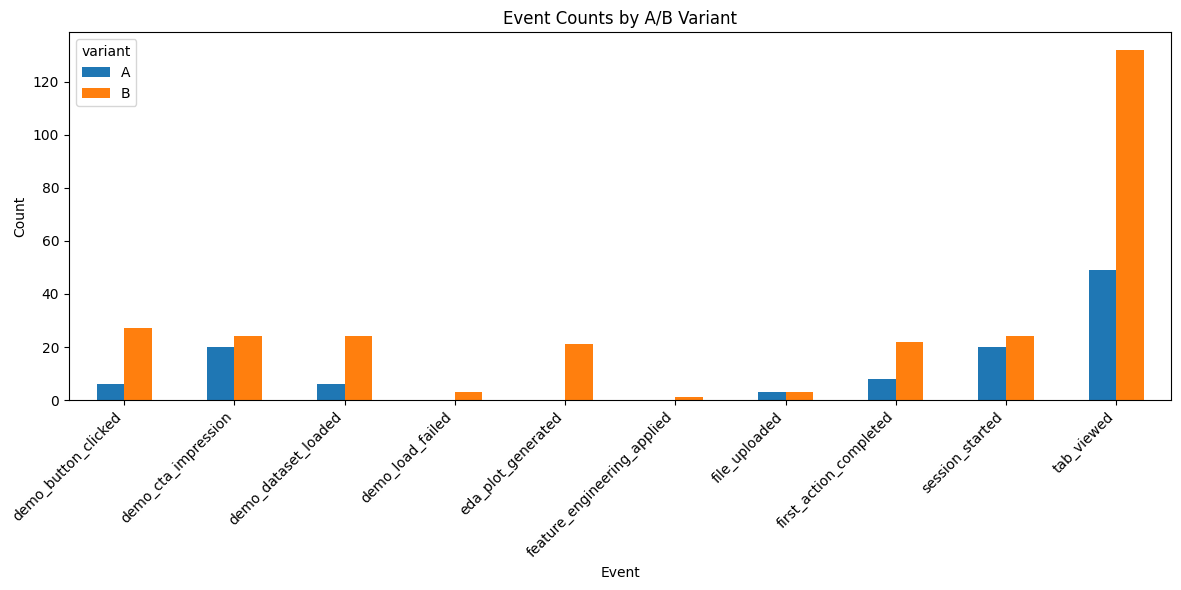

In [13]:
import matplotlib.pyplot as plt

# Create output folder on Desktop
eda_output_dir = r"C:/Users/35759/Desktop/ab_test_eda_outputs"
os.makedirs(eda_output_dir, exist_ok=True)

event_pivot = event_counts.pivot(
    index="event",
    columns="variant",
    values="event_count"
).fillna(0)

event_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("Event Counts by A/B Variant")
plt.xlabel("Event")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

fig1_path = os.path.join(eda_output_dir, "fig1_event_counts_by_variant.png")
plt.savefig(fig1_path, dpi=300)
plt.show()


# Figure 2: Funnel counts by variant

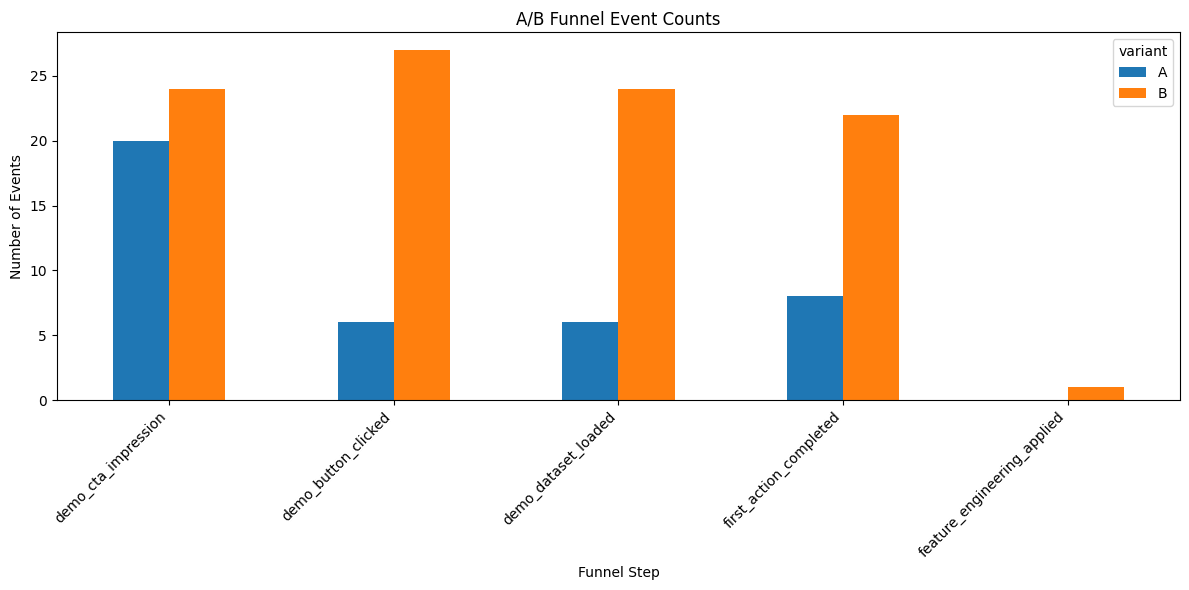

In [14]:
funnel_events = [
    "demo_cta_impression",
    "demo_button_clicked",
    "demo_dataset_loaded",
    "first_action_completed",
    "cleaning_options_applied",
    "feature_engineering_applied"
]

funnel_counts = (
    ab_data[ab_data["event"].isin(funnel_events)]
    .groupby(["variant", "event"])
    .size()
    .reset_index(name="count")
)

funnel_counts["event"] = pd.Categorical(
    funnel_counts["event"],
    categories=funnel_events,
    ordered=True
)

funnel_pivot = (
    funnel_counts
    .pivot(index="event", columns="variant", values="count")
    .fillna(0)
    .sort_index()
)

funnel_pivot.plot(kind="bar", figsize=(12, 6))

plt.title("A/B Funnel Event Counts")
plt.xlabel("Funnel Step")
plt.ylabel("Number of Events")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

fig2_path = os.path.join(eda_output_dir, "fig2_funnel_counts_by_variant.png")
plt.savefig(fig2_path, dpi=300)
plt.show()

# Figure 3: Main A/B metric rates

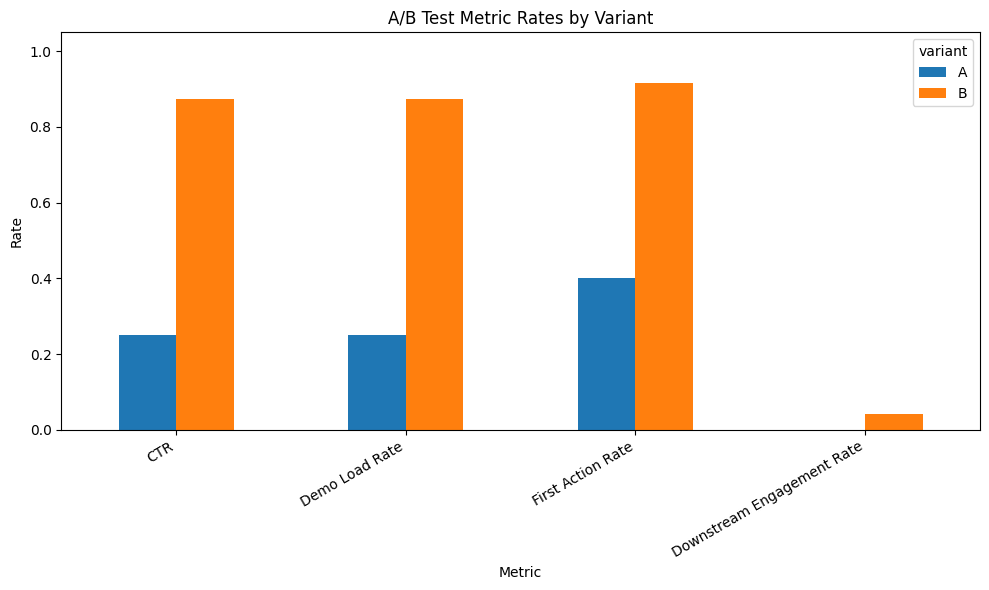

In [15]:


metric_cols = [
    "ctr",
    "demo_load_rate",
    "first_action_rate",
    "downstream_engagement_rate"
]

metric_labels = {
    "ctr": "CTR",
    "demo_load_rate": "Demo Load Rate",
    "first_action_rate": "First Action Rate",
    "downstream_engagement_rate": "Downstream Engagement Rate"
}

metric_plot_data = ab_summary[["variant"] + metric_cols].copy()
metric_plot_data = metric_plot_data.set_index("variant")
metric_plot_data = metric_plot_data.rename(columns=metric_labels)

metric_plot_data.T.plot(kind="bar", figsize=(10, 6))

plt.title("A/B Test Metric Rates by Variant")
plt.xlabel("Metric")
plt.ylabel("Rate")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

fig3_path = os.path.join(eda_output_dir, "fig3_metric_rates_by_variant.png")
plt.savefig(fig3_path, dpi=300)
plt.show()

# Figure 4: Demo dataset load rate with simple confidence intervals

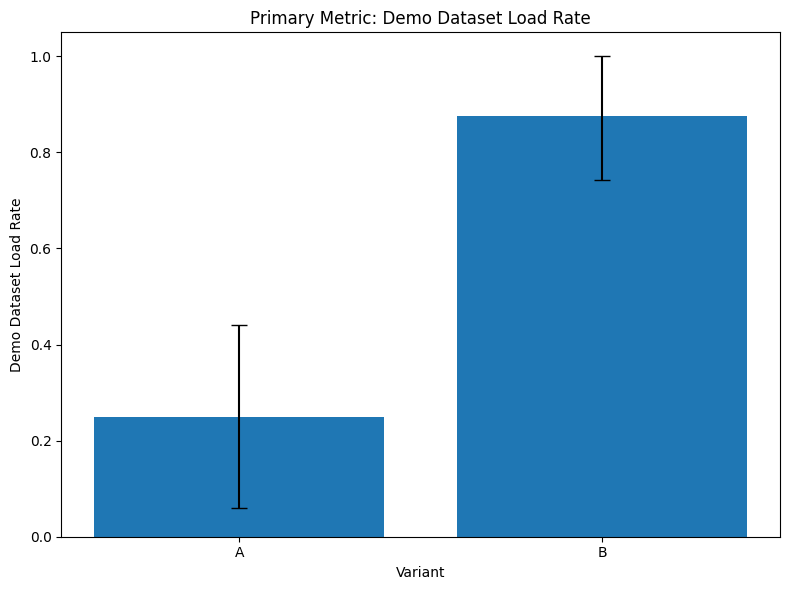

In [16]:
load_rate_data = (
    analysis_data
    .groupby("variant")
    .agg(
        successes=("loaded_demo_dataset", "sum"),
        total=("session_id", "count")
    )
    .reset_index()
    .sort_values("variant")
)

load_rate_data["rate"] = load_rate_data["successes"] / load_rate_data["total"]

# Approximate standard error for a sample proportion
load_rate_data["se"] = np.sqrt(
    load_rate_data["rate"] * (1 - load_rate_data["rate"]) / load_rate_data["total"]
)

load_rate_data["ci_lower"] = load_rate_data["rate"] - 1.96 * load_rate_data["se"]
load_rate_data["ci_upper"] = load_rate_data["rate"] + 1.96 * load_rate_data["se"]

load_rate_data["ci_lower"] = load_rate_data["ci_lower"].clip(lower=0)
load_rate_data["ci_upper"] = load_rate_data["ci_upper"].clip(upper=1)

plt.figure(figsize=(8, 6))

plt.bar(
    load_rate_data["variant"],
    load_rate_data["rate"],
    yerr=[
        load_rate_data["rate"] - load_rate_data["ci_lower"],
        load_rate_data["ci_upper"] - load_rate_data["rate"]
    ],
    capsize=6
)

plt.title("Primary Metric: Demo Dataset Load Rate")
plt.xlabel("Variant")
plt.ylabel("Demo Dataset Load Rate")
plt.ylim(0, 1.05)
plt.tight_layout()

fig4_path = os.path.join(eda_output_dir, "fig4_demo_load_rate_ci.png")
plt.savefig(fig4_path, dpi=300)
plt.show()


# Figure 5: Time to first action by variant

C:\Users\35759\AppData\Local\Temp\ipykernel_31028\3335271378.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(time_values, labels=variants)


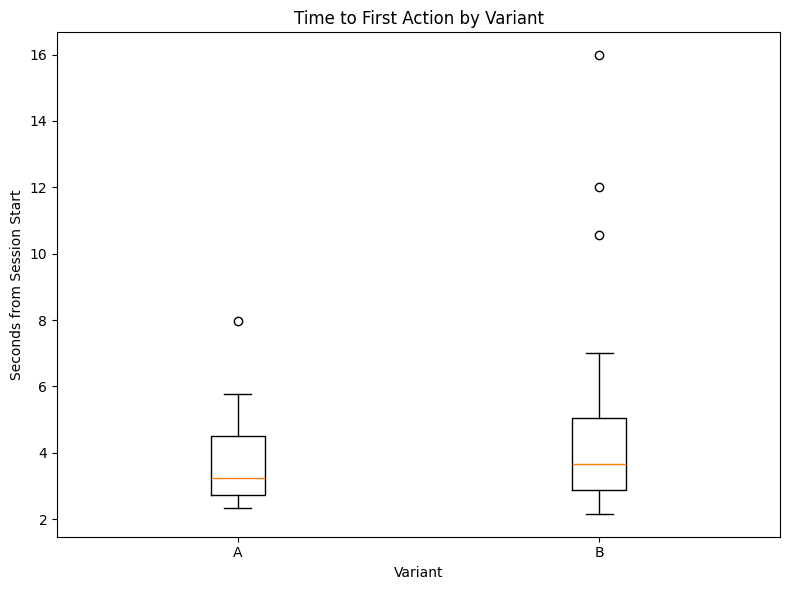

In [17]:
time_data = analysis_data.dropna(subset=["time_to_first_action"]).copy()

if len(time_data) > 0:
    variants = sorted(time_data["variant"].unique())
    time_values = [
        time_data.loc[time_data["variant"] == v, "time_to_first_action"]
        for v in variants
    ]

    plt.figure(figsize=(8, 6))
    plt.boxplot(time_values, labels=variants)

    plt.title("Time to First Action by Variant")
    plt.xlabel("Variant")
    plt.ylabel("Seconds from Session Start")
    plt.tight_layout()

    fig5_path = os.path.join(eda_output_dir, "fig5_time_to_first_action.png")
    plt.savefig(fig5_path, dpi=300)
    plt.show()
else:
    print("No time_to_first_action values available for Figure 5.")


# Figure 6: Session-level outcome heatmap-style table

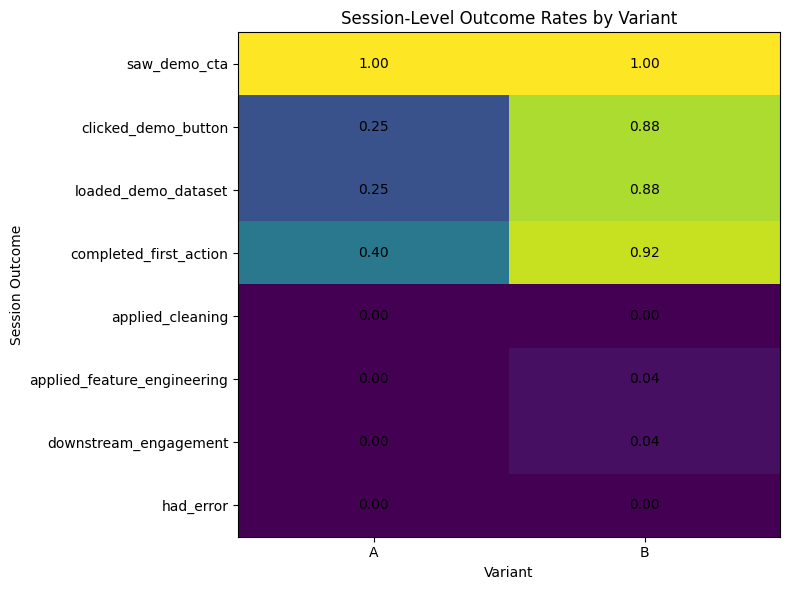


EDA figures saved to:
C:/Users/35759/Desktop/ab_test_eda_outputs
C:/Users/35759/Desktop/ab_test_eda_outputs\fig1_event_counts_by_variant.png
C:/Users/35759/Desktop/ab_test_eda_outputs\fig2_funnel_counts_by_variant.png
C:/Users/35759/Desktop/ab_test_eda_outputs\fig3_metric_rates_by_variant.png
C:/Users/35759/Desktop/ab_test_eda_outputs\fig4_demo_load_rate_ci.png
C:/Users/35759/Desktop/ab_test_eda_outputs\fig5_time_to_first_action.png
C:/Users/35759/Desktop/ab_test_eda_outputs\fig6_session_outcome_rates.png


In [18]:
session_outcome_cols = [
    "saw_demo_cta",
    "clicked_demo_button",
    "loaded_demo_dataset",
    "completed_first_action",
    "applied_cleaning",
    "applied_feature_engineering",
    "downstream_engagement",
    "had_error"
]

session_rate_table = (
    analysis_data
    .groupby("variant")[session_outcome_cols]
    .mean()
    .T
)

plt.figure(figsize=(8, 6))
plt.imshow(session_rate_table.values, aspect="auto")

plt.title("Session-Level Outcome Rates by Variant")
plt.xlabel("Variant")
plt.ylabel("Session Outcome")

plt.xticks(
    ticks=np.arange(len(session_rate_table.columns)),
    labels=session_rate_table.columns
)

plt.yticks(
    ticks=np.arange(len(session_rate_table.index)),
    labels=session_rate_table.index
)

for i in range(session_rate_table.shape[0]):
    for j in range(session_rate_table.shape[1]):
        plt.text(
            j,
            i,
            f"{session_rate_table.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.tight_layout()

fig6_path = os.path.join(eda_output_dir, "fig6_session_outcome_rates.png")
plt.savefig(fig6_path, dpi=300)
plt.show()


print("\n==============================")
print("EDA figures saved to:")
print("==============================")
print(eda_output_dir)
print(fig1_path)
print(fig2_path)
print(fig3_path)
print(fig4_path)
if len(time_data) > 0:
    print(fig5_path)
print(fig6_path)